# Zweiter Ansatz

In [1]:
# import graveyard

# from sklearn.model_selection import train_test_split
# from sklearn.tree import DecisionTreeClassifier
# import matplotlib.pyplot as plt
# from sklearn import tree
# from typing import Tuple, List, Optional, Any # For type hinting
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from xgboost import XGBClassifier
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
# import matplotlib.pyplot as plt
# from collections import Counter
# import numpy as np
# import re

## Caching Setup

In [1]:
# setup caching via csv files
import os
import pandas as pd

CACHE_DIR = './cache/20_imdb'

# Ensure the cache directory exists
if not os.path.exists(CACHE_DIR):
    os.makedirs(CACHE_DIR)

def write_df_to_csv(df, filename):
    """
    Write a DataFrame to a CSV file in the cache directory.
    """
    filepath = os.path.join(CACHE_DIR, filename)
    df.to_csv(filepath, index=False)

def read_df_from_csv(filename):
    """
    Read a DataFrame from a CSV file in the cache directory.
    """
    filepath = os.path.join(CACHE_DIR, filename)
    if os.path.exists(filepath):
        return pd.read_csv(filepath)
    else:
        raise FileNotFoundError(f"Cache file {filename} not found in {CACHE_DIR}.")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\laure\anaconda3\envs\hsmainz2025_prod\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\laure\anaconda3\envs\hsmainz2025_prod\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "c:\Users\laure\anaconda3\envs\hsmainz2025_prod\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\laure\anaconda3\envs\hsmainz2025_prod\lib\site-packages\traitlets\config\application.py", lin

AttributeError: _ARRAY_API not found

- download der TMDB und IMDB Daten
- entfernen der Spalten, die nicht benötigt werden aus dem TMDB und IMDB Datensatz
- zusammenführen der beiden Datensätze

In [3]:
from kagglehub import KaggleDatasetAdapter, dataset_load
import gc

# Load both datasets from Kaggle
df_tmdb = dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "asaniczka/tmdb-movies-dataset-2023-930k-movies/versions/518",
    "TMDB_movie_dataset_v11.csv",)

df_imdb = dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "ashirwadsangwan/imdb-dataset",
    "title.basics.tsv",)

# drop unnecessary columns from both dataframes
df_tmdb_drop_colums = df_tmdb.drop(columns=['id', 'status', 'backdrop_path', 'poster_path', 'homepage'])
df_imdb_drop_colums = df_imdb.drop(columns=['isAdult', 'startYear', 'endYear', 'runtimeMinutes'])

# filter the IMDb dataframe to only include movies
df_only_movies = df_imdb_drop_colums[df_imdb_drop_colums["titleType"] == "movie"]

# Merge the dataframes on IMDb ID
merged_df = df_tmdb_drop_colums.merge(
    df_only_movies,
    left_on='imdb_id',
    right_on='tconst',
    how='inner'
)

print(merged_df.shape)
print(merged_df.head())

write_df_to_csv(merged_df, 'merged_tmdb_imdb.csv')

# Free up memory
del df_tmdb
del df_imdb
del df_imdb_drop_colums
del df_tmdb_drop_colums
del df_only_movies
del merged_df
gc.collect()

c:\Users\laure\anaconda3\envs\hsmainz2025_prod\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Download already complete (1012050034 bytes).


c:\Users\laure\anaconda3\envs\hsmainz2025_prod\lib\site-packages\kagglehub\pandas_datasets.py:91: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  result = read_function(


(337380, 24)
             title  vote_average  vote_count release_date     revenue  \
0        Inception         8.364       34495   2010-07-15   825532764   
1     Interstellar         8.417       32571   2014-11-05   701729206   
2  The Dark Knight         8.512       30619   2008-07-16  1004558444   
3           Avatar         7.573       29815   2009-12-15  2923706026   
4     The Avengers         7.710       29166   2012-04-25  1518815515   

   runtime  adult     budget    imdb_id original_language  ...  \
0      148  False  160000000  tt1375666                en  ...   
1      169  False  165000000  tt0816692                en  ...   
2      152  False  185000000  tt0468569                en  ...   
3      162  False  237000000  tt0499549                en  ...   
4      143  False  220000000  tt0848228                en  ...   

                                      genres_x  \
0           Action, Science Fiction, Adventure   
1            Adventure, Drama, Science Fiction   
2

0

- entfernen der Filme mit weniger als 10 Bewertungen

In [4]:
import gc

merged_df = read_df_from_csv('merged_tmdb_imdb.csv')

# Filter merged_df for movies with vote_count >= 10
df_filtered = merged_df[merged_df['vote_count'] >= 10]

# Display basic information about the filtered dataset
print("Shape of filtered dataset:", df_filtered.shape)

write_df_to_csv(df_filtered, 'filtered_tmdb_imdb.csv')

# free up memory
del merged_df
del df_filtered
gc.collect()

Shape of filtered dataset: (62056, 24)


0

- Laden der Informationen über die Schauspieler

In [5]:
# from kagglehub import KaggleDatasetAdapter, dataset_load
# import gc

# df_imdb_principals = dataset_load(
#     KaggleDatasetAdapter.PANDAS,
#     "ashirwadsangwan/imdb-dataset",
#     "title.principals.tsv",)

# df_imdb_principals_only_relevant = df_imdb_principals[['tconst', 'nconst', 'category']].rename(columns={'nconst': 'actor', 'tconst': 'imdb_id'})

# df_imdb_principals_only_relevant.head(5)

# write_df_to_csv(df_imdb_principals_only_relevant, 'imdb_principals_only_relevant.csv')

# # free up memory
# del df_imdb_principals
# gc.collect()

# Code from experiments:

# # Get list of valid IMDB IDs from filtered_df
# valid_imdb_ids = df_filtered['imdb_id'].unique()

# # Filter df_only_relevant to only include those IDs
# df_only_relevant = df_only_relevant[df_only_relevant['imdb_id'].isin(valid_imdb_ids)]
# df_only_relevant.head(5)  # Display the first 5 rows of the filtered dataset

# cast_by_movie = df_only_relevant.groupby('imdb_id').apply(
#     lambda x: pd.Series({
#         'cast': [{'actor': actor, 'category': category} 
#                 for actor, category in zip(x['actor'], x['category'])]
#     })
# ).reset_index()

# # Then merge with the filtered movie data
# merged_principals_df = df_filtered.merge(
#     cast_by_movie,
#     on='imdb_id',
#     how='inner'
# )

# print("Shape of merged dataset with principals:", merged_principals_df.shape)
# # Display example of the new structure
# print("\nSample of merged data with actor-category pairs:")
# print(merged_principals_df[['imdb_id', 'cast']].head(10))

# del df_only_relevant  # Free up memory
# del cast_by_movie  # Free up memory
# del df_filtered  # Free up memory

- encoden der genres, produktionsländer, gesprochene sprachen, originalsprache, produktionsfirmen

In [2]:
from sklearn.preprocessing import MultiLabelBinarizer
import gc

df_filtered = read_df_from_csv('filtered_tmdb_imdb.csv')

df_encoded = df_filtered.copy()

# create helper functions
def split_list_string(x):
    """
    Convert a string representation of a list into an actual list.
    If the input is a string, it splits by commas and strips whitespace.
    If the input is not a string, it returns an empty list.
    """
    if isinstance(x, str):
        return [item.strip() for item in x.split(',')]
    return []

def clean_feature_name(name):
    """
    Clean the feature name by removing brackets and replacing angle brackets with underscores.
    """
    return name.replace('[', '').replace(']', '').replace('<', '_').replace('>', '_')

# decide which columns to encode
columns_to_encode = [
    'genres_x', 
    'production_countries', 
    'spoken_languages', 
    'original_language',
]

# Create MultiLabelBinarizer for each column
encoders = {}
encoded_dfs = {}

for column in columns_to_encode:
    # Split the strings into lists
    df_encoded[column] = df_encoded[column].fillna('').apply(split_list_string)
    
    # Create and fit the encoder
    mlb = MultiLabelBinarizer()
    encoded_array = mlb.fit_transform(df_encoded[column])
    
    # Create DataFrame with encoded values
    encoded_df = pd.DataFrame(
        encoded_array,
        columns=[f'{column}_{label}' for label in mlb.classes_],
        index=df_filtered.index
    )
    
    # Store the encoded DataFrame
    encoded_dfs[column] = encoded_df
    encoders[column] = mlb

# Concatenate all encoded features with original dataframe
df_encoded = pd.concat([df_encoded] + list(encoded_dfs.values()), axis=1)

# Drop original categorical columns
df_encoded = df_encoded.drop(columns=columns_to_encode)


print("Shape of the DataFrame before encoding:", df_filtered.shape)
print("Shape after encoding:", df_encoded.shape)


# NEVER EVER DO I WANT TO WARITE THIS TO DISK AGAIN IT TAKES FOREVER
# Uncomment the line below to write the encoded DataFrame to a CSV file
#write_df_to_csv(df_encoded, 'encoded_tmdb_imdb.csv') 

# Clean up memory
# seems to have caused a loop between swap and memory
# del df_filtered
# del encoded_dfs
# gc.collect()

Shape of the DataFrame before encoding: (62056, 24)
Shape after encoding: (62056, 487)


Selected features: ['revenue', 'runtime', 'adult', 'budget', 'genres_x_', 'genres_x_Action', 'genres_x_Adventure', 'genres_x_Animation', 'genres_x_Comedy', 'genres_x_Crime', 'genres_x_Documentary', 'genres_x_Drama', 'genres_x_Family', 'genres_x_Fantasy', 'genres_x_History', 'genres_x_Horror', 'genres_x_Music', 'genres_x_Mystery', 'genres_x_Romance', 'genres_x_Science Fiction', 'genres_x_TV Movie', 'genres_x_Thriller', 'genres_x_War', 'genres_x_Western', 'production_countries_', 'production_countries_Afghanistan', 'production_countries_Albania', 'production_countries_Algeria', 'production_countries_Andorra', 'production_countries_Angola', 'production_countries_Antarctica', 'production_countries_Argentina', 'production_countries_Armenia', 'production_countries_Aruba', 'production_countries_Australia', 'production_countries_Austria', 'production_countries_Azerbaijan', 'production_countries_Bahamas', 'production_countries_Bangladesh', 'production_countries_Belarus', 'production_countries_B

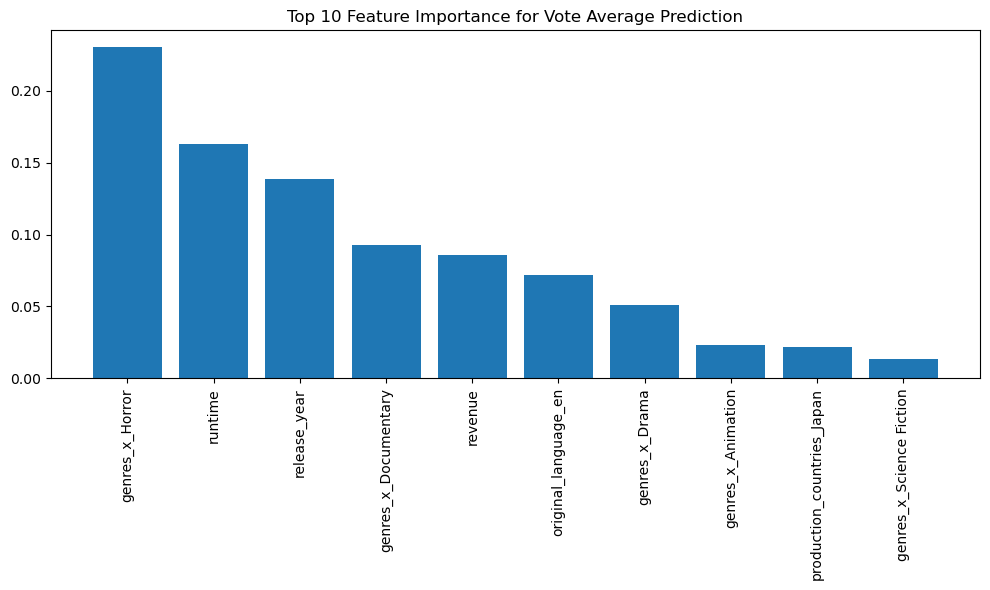

In [ ]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import datetime

# Preprocess the data
# Extract year from release_date
df_encoded['release_year'] = pd.to_datetime(df_encoded['release_date'], errors='coerce').dt.year

# Select features for prediction - be more specific about excluded columns
exclude_cols = [
    'vote_average', 'vote_count', 'popularity', 'title', 'original_title',
    'overview', 'tagline', 'keywords', 'imdb_id', 'tconst', 'primaryTitle',
    'originalTitle', 'release_date', 'genres_x', 'genres_y', 'production_companies',
    'production_countries', 'spoken_languages', 'titleType', 'original_language', 'revenue'
]

# Keep only numerical and boolean columns
feature_cols = []
for col in df_encoded.columns:
    if col not in exclude_cols:
        # Check if column is numeric or boolean
        if df_encoded[col].dtype in ['int64', 'float64', 'bool']:
            feature_cols.append(col)
        # For binary columns that might be strings
        elif df_encoded[col].nunique() == 2:
            df_encoded[col] = pd.get_dummies(df_encoded[col], drop_first=True)
            feature_cols.append(col)

# Handle missing values and select features
X = df_encoded[feature_cols].fillna(0)
y = df_encoded['vote_average']

print("Selected features:", feature_cols)
print("Feature matrix shape:", X.shape)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the decision tree
dt_regressor = DecisionTreeRegressor(max_depth=10, min_samples_split=10, random_state=42)
dt_regressor.fit(X_train, y_train)

# Make predictions and evaluate
y_pred = dt_regressor.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Performance:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_regressor.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

print("\nTop 10 Important Features:")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.bar(feature_importance['Feature'], feature_importance['Importance'])
plt.xticks(rotation=90)
plt.title('Top 10 Feature Importance for Vote Average Prediction')
plt.tight_layout()
plt.show()